In [14]:
import sys
sys.path.append('./my_custom_packages')

import os
import scanpy as sc
import anndata as ad
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.sparse as sp
from concurrent.futures import ProcessPoolExecutor
import re
os.chdir("/stor/scratch/FRI-BigDataBio/FRI_summer_2026/frog_data")
import scvi


In [8]:

np.random.seed(123)

filtered_counts_gn = sc.read_10x_h5("TF_GN_outs/outs/filtered_feature_bc_matrix.h5")
filtered_counts_gn.obs['project'] = "Green-noise"
filtered_counts_gn.obs_names = "GN_" + filtered_counts_gn.obs_names

filtered_counts_wc = sc.read_10x_h5("TF_WC_outs/outs/filtered_feature_bc_matrix.h5")
filtered_counts_wc.obs['project'] = "Whine-chuck"
filtered_counts_wc.obs_names = "WC_" + filtered_counts_wc.obs_names

filtered_counts_w = sc.read_10x_h5("TF_W_outs/outs/filtered_feature_bc_matrix.h5")
filtered_counts_w.obs['project'] = "Whine"
filtered_counts_w.obs_names = "W_" + filtered_counts_w.obs_names

# Merge the objects
tunga_frog_merged = ad.concat([filtered_counts_gn, filtered_counts_wc, filtered_counts_w])

# tunga_frog_merged.write_h5ad("tunga_frog_01_raw.h5ad")
print("Saved.")

Saved.


In [6]:
tunga_frog_merged = sc.read_h5ad("tunga_frog_01_raw.h5ad")

# QC metrics to filter by nFeature_RNA
sc.pp.calculate_qc_metrics(tunga_frog_merged, percent_top=None, log1p=False, inplace=True)

# nFeature_RNA > 500 and nFeature_RNA < 6000)
sc.pp.filter_cells(tunga_frog_merged, min_genes=500)
tunga_frog_merged = tunga_frog_merged[tunga_frog_merged.obs.n_genes_by_counts < 6000, :]

# Save raw counts in a layer before modifying X (equivalent to Seurat's 'counts' layer)
tunga_frog_merged.layers["counts"] = tunga_frog_merged.X.copy()

sc.pp.normalize_total(tunga_frog_merged, target_sum=1e4)
sc.pp.log1p(tunga_frog_merged)
sc.pp.highly_variable_genes(tunga_frog_merged, n_top_genes=2000)

sc.pp.scale(tunga_frog_merged, max_value=10)
sc.tl.pca(tunga_frog_merged, svd_solver='arpack')

#tunga_frog_merged.write_h5ad("tunga_frog_02_processed.h5ad")
print("Saved.")

/tmp/ipykernel_286879/4268569445.py:11: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  tunga_frog_merged.layers["counts"] = tunga_frog_merged.X.copy()


Saved processed data.


In [7]:
tunga_frog_merged = sc.read_h5ad("tunga_frog_02_processed.h5ad")

sc.pp.neighbors(tunga_frog_merged, n_neighbors=10, n_pcs=20)
sc.tl.leiden(tunga_frog_merged, resolution=0.2, key_added='seurat_clusters')

sc.tl.umap(tunga_frog_merged)

# Find all Markers 
sc.tl.rank_genes_groups(
    tunga_frog_merged, 
    groupby='seurat_clusters', 
    method='wilcoxon',
    use_raw=False,
    pts=True 
)

# Markers to a Polars Dataframe
result = tunga_frog_merged.uns['rank_genes_groups']
groups = result['names'].dtype.names
marker_df_list = []

for group in groups:
    df = pl.DataFrame({
        'gene': result['names'][group],
        'scores': result['scores'][group],
        'pvals_adj': result['pvals_adj'][group],
        'logfoldchanges': result['logfoldchanges'][group],
        'cluster': group
    })
    # Only positive markers
    df = df.filter((pl.col('scores') > 0) & (pl.col('logfoldchanges') > 0.25))
    marker_df_list.append(df)

markers_pl = pl.concat(marker_df_list)

#tunga_frog_merged.write_h5ad("tunga_frog_03_clustered.h5ad")
#markers_pl.write_parquet("tunga_frog_markers.parquet")
print("Saved.")

2026-06-05 13:17:33.699550: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-05 13:17:33.712844: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780683453.726604  286879 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780683453.730584  286879 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-05 13:17:33.745945: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Saved clustered data and markers.


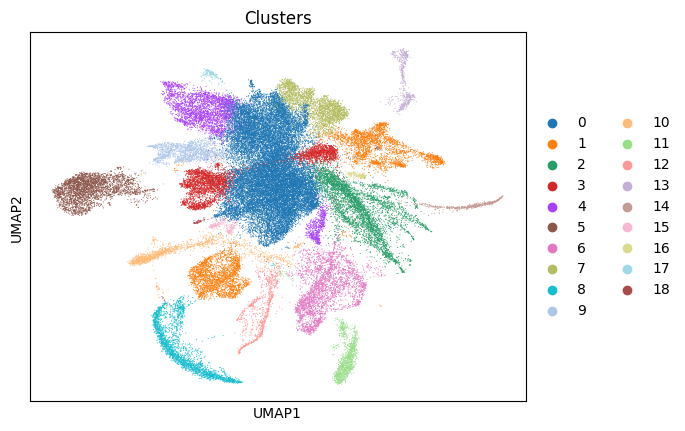

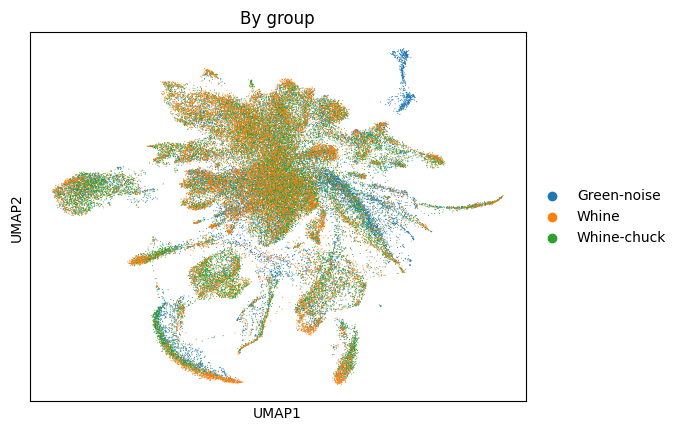

In [8]:
tunga_frog_merged = sc.read_h5ad("tunga_frog_03_clustered.h5ad")

sc.pl.umap(
    tunga_frog_merged, 
    color=['seurat_clusters'],
    title=['Clusters'],
    show=False              # False so we can save it using matplotlib
)
plt.savefig("tunga_frog_umap_clusters.png")
plt.show()


sc.pl.umap(
    tunga_frog_merged, 
    color=['project'],
    title=['By group'],
    show=False              
)

plt.savefig("tunga_frog_umap_group.png")
plt.show()


In [4]:
# Load the Xenopus brain count matrices 
# ------------------------------------------------------------------------------
brain1 = ad.AnnData(pd.read_csv("GSM6214268_Xenopus_brain_COL65_dge.txt", sep="\t", index_col=0).T)
brain2 = ad.AnnData(pd.read_csv("GSM6214269_Xenopus_brain_COL66_dge.txt", sep="\t", index_col=0).T)
brain3 = ad.AnnData(pd.read_csv("GSM6214270_Xenopus_brain_COL124_dge.txt", sep="\t", index_col=0).T)
brain4 = ad.AnnData(pd.read_csv("GSM6214271_Xenopus_brain_COL127_dge.txt", sep="\t", index_col=0).T)

xeno_brain = ad.concat(
    {"b1": brain1, "b2": brain2, "b3": brain3, "b4": brain4},
    label="batch",
    index_unique="_" 
)

xeno_brain.layers["counts"] = xeno_brain.X.copy()
sc.pp.normalize_total(xeno_brain, target_sum=1e4)
sc.pp.log1p(xeno_brain)
sc.pp.highly_variable_genes(xeno_brain, n_top_genes=2000)

/opt/jupyterhub/pyvenv/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:233: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [5]:
# Reference metadata
# ------------------------------------------------------------------------------
xeno_meta = pd.read_csv("Brain_cell_info.csv", index_col=0)

# Matches the entire string, saves the "Brain[digit]_[digit]" part, and replaces the whole string with just that saved part.
seurat_batch = xeno_brain.obs_names.to_series().str.extract(r'(Brain\d_\d)')[0]

# Matches everything from the start up to the very last dot, and deletes it all.
seurat_dna = xeno_brain.obs_names.to_series().str.split('.').str[-1]
xeno_brain.obs['merge_key'] = seurat_batch + "_" + seurat_dna

meta_batch = xeno_meta.index.to_series().str.extract(r'(Brain\d_\d)')[0]
meta_dna = xeno_meta.index.to_series().str.split('.').str[-1]
xeno_meta['merge_key'] = meta_batch + "_" + meta_dna

cluster_dict = xeno_meta.set_index('merge_key')['cluster'].to_dict()
xeno_brain.obs['cluster'] = xeno_brain.obs['merge_key'].map(cluster_dict)

xeno_brain = xeno_brain[xeno_brain.obs['cluster'].notna()].copy()